# Predicting Customer Churn & Business ROI
**Goal:** Build a machine learning classification model to predict whether a telecom customer will cancel their subscription, and calculate the financial impact of deploying this model.
**Key Skills:** Data Cleaning, EDA, Handling Class Imbalance (SMOTE), Random Forest Classification, Business ROI Calculation.

In [1]:
import pandas as pd

# Load the Telco Customer Churn dataset directly from a raw URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print("\nTarget Variable Distribution:")
print(df['Churn'].value_counts(normalize=True) * 100) # Shows the percentage of Yes vs No

df.head()

Dataset shape: (7043, 21)

Target Variable Distribution:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset shape (Rows, Columns): (7043, 21)



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


--- Churn Distribution ---
Raw Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64%



/tmp/ipykernel_1483/2299469870.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#4C72B0', '#C44E52'])


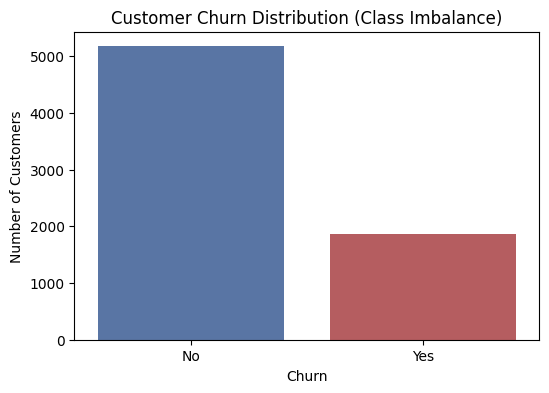

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# 2. Quick look at the dataset size and first few rows
print(f"Dataset shape (Rows, Columns): {df.shape}\n")
display(df.head())

# 3. Inspect the Target Variable ('Churn')
# Let's get the exact numbers and the percentages
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("--- Churn Distribution ---")
print(f"Raw Counts:\n{churn_counts}\n")
print(f"Percentages:\n{churn_percentages.round(2)}%\n")

# 4. Visualize the Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette=['#4C72B0', '#C44E52'])
plt.title('Customer Churn Distribution (Class Imbalance)')
plt.ylabel('Number of Customers')
plt.show()

In [3]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [4]:
# 1. Force 'TotalCharges' to be a number.
# The 'coerce' command tells Pandas: "If you find a blank space or text, turn it into a NaN (Not a Number)."
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Let's see how many blank spaces we just exposed
missing_values = df['TotalCharges'].isnull().sum()
print(f"Hidden missing values found in TotalCharges: {missing_values}")

# 3. Since it's only 11 rows out of 7,043, we can safely delete them without hurting our model
df.dropna(subset=['TotalCharges'], inplace=True)

# 4. Drop the 'customerID' column.
# An ID is just a random string of numbers. If the model tries to learn from it, it will just get confused.
df.drop('customerID', axis=1, inplace=True)

# 5. Verify the cleaning
print("\nNew Dataset Shape:", df.shape)
print("\nData Types to confirm TotalCharges is now a float:")
print(df[['MonthlyCharges', 'TotalCharges', 'tenure']].dtypes)

Hidden missing values found in TotalCharges: 11

New Dataset Shape: (7032, 20)

Data Types to confirm TotalCharges is now a float:
MonthlyCharges    float64
TotalCharges      float64
tenure              int64
dtype: object


In [5]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


## 1. Data Cleaning & Preprocessing
Real-world data is rarely perfect. Here, we fix hidden missing values (blank spaces masquerading as text in the `TotalCharges` column) and drop useless identifiers to prepare the data for the machine learning algorithm.

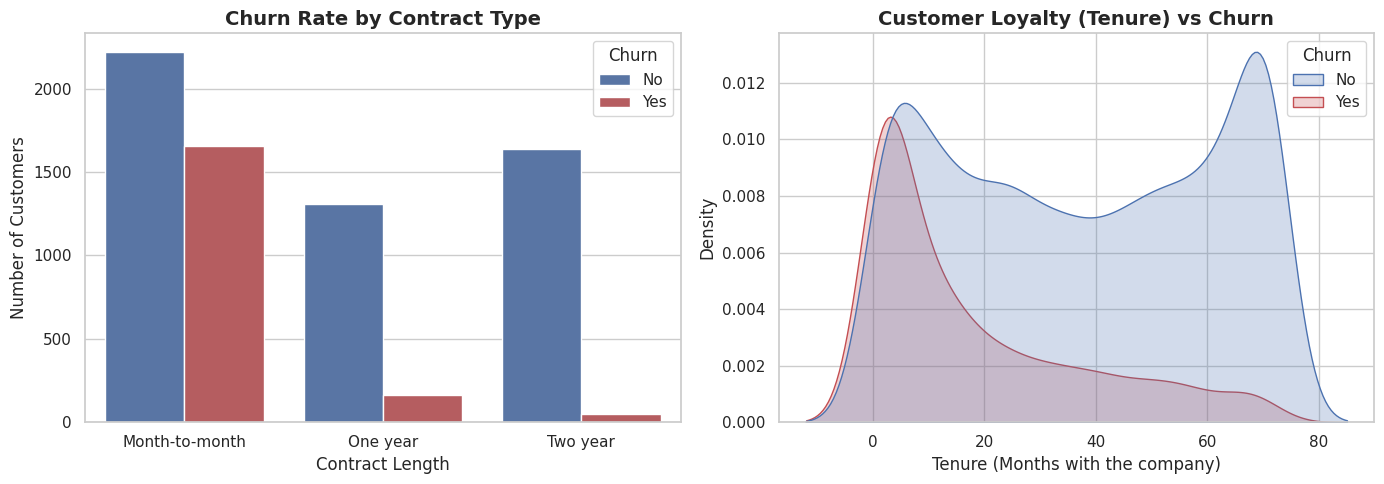

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a clean style for our charts
sns.set_theme(style="whitegrid")

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Categorical EDA (Contract Type vs Churn) ---
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#4C72B0', '#C44E52'], ax=axes[0])
axes[0].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Contract Length')
axes[0].set_ylabel('Number of Customers')

# --- Plot 2: Numerical EDA (Tenure vs Churn) ---
# A KDE plot (Kernel Density Estimate) shows the distribution of a numerical value
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette=['#4C72B0', '#C44E52'], ax=axes[1])
axes[1].set_title('Customer Loyalty (Tenure) vs Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tenure (Months with the company)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

## 2. Exploratory Data Analysis (EDA)
Before training the model, we visualize the data to find behavioral clues.
* **Contract Type:** Month-to-month customers churn at heavily inflated rates.
* **Tenure:** The first 6 months are the highest risk period for churn.

In [7]:
from sklearn.preprocessing import StandardScaler

# 1. Manually map the Target Variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separate our Features (X) and our Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. One-Hot Encoding for all categorical (text) columns
# We use drop_first=True to avoid the Dummy Variable Trap
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Scale the Numerical Columns
# We specifically pick out the continuous numbers
numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X_encoded[numerical_columns] = scaler.fit_transform(X_encoded[numerical_columns])

# Let's see what our data looks like now!
print(f"Old number of columns: {X.shape[1]}")
print(f"New number of columns: {X_encoded.shape[1]}\n")

print("Here is the mathematical matrix the model will actually 'see':")
display(X_encoded.head(1
                       ))

Old number of columns: 19
New number of columns: 30

Here is the mathematical matrix the model will actually 'see':


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.280248,-1.161694,-0.994194,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## 3. Handling Class Imbalance with SMOTE
Our target variable is highly imbalanced (~73% Stay, ~27% Churn). If we train a model on this, it will be biased toward predicting "Stay". We use **SMOTE (Synthetic Minority Over-sampling Technique)** on the *training data only* to mathematically generate synthetic churners and level the playing field.

In [8]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. The Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("--- BEFORE SMOTE (Training Data) ---")
print(f"Churners (1):     {sum(y_train == 1)}")
print(f"Non-Churners (0): {sum(y_train == 0)}")
print("Notice the massive imbalance!\n")

# 2. Initialize and apply SMOTE to the TRAINING DATA ONLY
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("--- AFTER SMOTE (Training Data) ---")
print(f"Churners (1):     {sum(y_train_balanced == 1)}")
print(f"Non-Churners (0): {sum(y_train_balanced == 0)}")
print("Perfectly balanced! The model now has an equal amount of examples to learn from.")

--- BEFORE SMOTE (Training Data) ---
Churners (1):     1495
Non-Churners (0): 4130
Notice the massive imbalance!

--- AFTER SMOTE (Training Data) ---
Churners (1):     4130
Non-Churners (0): 4130
Perfectly balanced! The model now has an equal amount of examples to learn from.


## 4. Model Training & Evaluation
We train a baseline Logistic Regression model and a complex Random Forest Classifier. Because we are dealing with an imbalanced business problem, we discard "Accuracy" and evaluate the models using the **Confusion Matrix, Precision, and Recall**.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the models
# (We increase max_iter for Logistic Regression so the math has enough time to finish)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the models on the BALANCED training data
print("Training Logistic Regression...")
log_reg.fit(X_train_balanced, y_train_balanced)

print("Training Random Forest...")
rf_model.fit(X_train_balanced, y_train_balanced)

# 3. Make predictions on the UNTOUCHED test data
log_pred = log_reg.predict(X_test)
rf_pred = rf_model.predict(X_test)

print("\nSuccess! Both models have learned from the data and made their predictions on the Test set.")

Training Logistic Regression...
Training Random Forest...

Success! Both models have learned from the data and made their predictions on the Test set.


## 5. Translating Metrics into Business ROI
A model is only useful if it makes or saves money. Here, we assign a dollar value to our False Positives (wasted promo codes) and True Positives (saved revenue) to prove the Net Return on Investment (ROI) of deploying this Random Forest model.

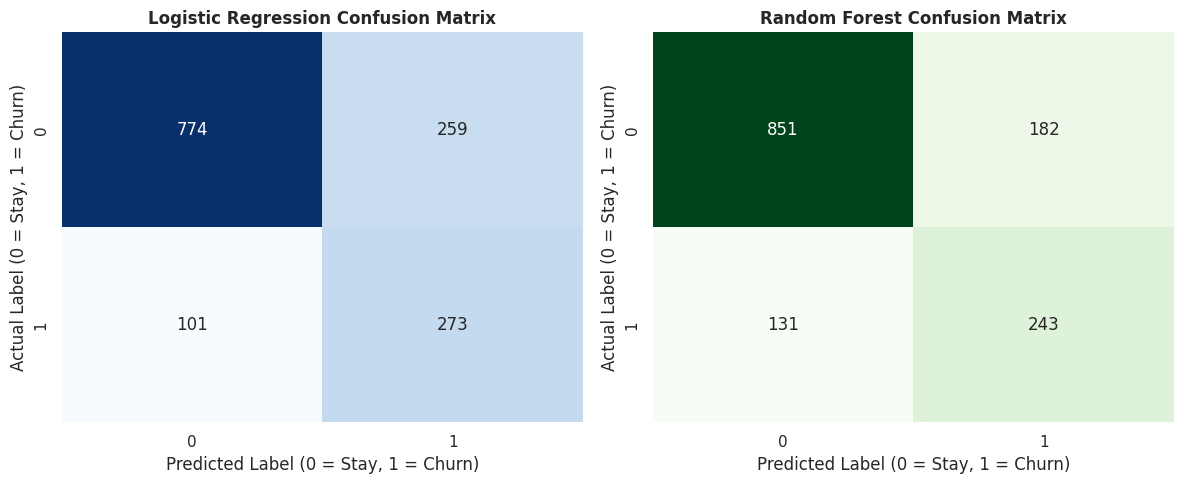

--- Logistic Regression Metrics ---
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1033
           1       0.51      0.73      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.74      0.76      1407


--- Random Forest Metrics ---
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1033
           1       0.57      0.65      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407



In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure to show two matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Model 1: Logistic Regression Matrix ---
cm_log = confusion_matrix(y_test, log_pred)
# We use fmt='d' to display whole numbers instead of scientific notation
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Logistic Regression Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label (0 = Stay, 1 = Churn)')
axes[0].set_ylabel('Actual Label (0 = Stay, 1 = Churn)')

# --- Model 2: Random Forest Matrix ---
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Random Forest Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted Label (0 = Stay, 1 = Churn)')
axes[1].set_ylabel('Actual Label (0 = Stay, 1 = Churn)')

plt.tight_layout()
plt.show()

# --- Print the detailed metrics ---
print("--- Logistic Regression Metrics ---")
print(classification_report(y_test, log_pred))

print("\n--- Random Forest Metrics ---")
print(classification_report(y_test, rf_pred))

/tmp/ipykernel_1483/717732669.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_bottom_coeffs, palette='coolwarm')


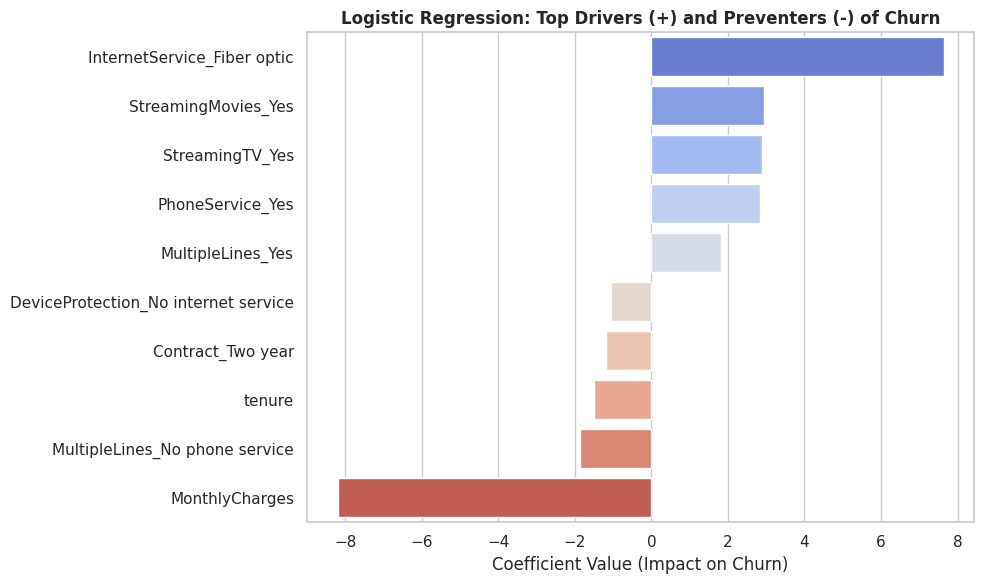

/tmp/ipykernel_1483/717732669.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(10), palette='viridis')


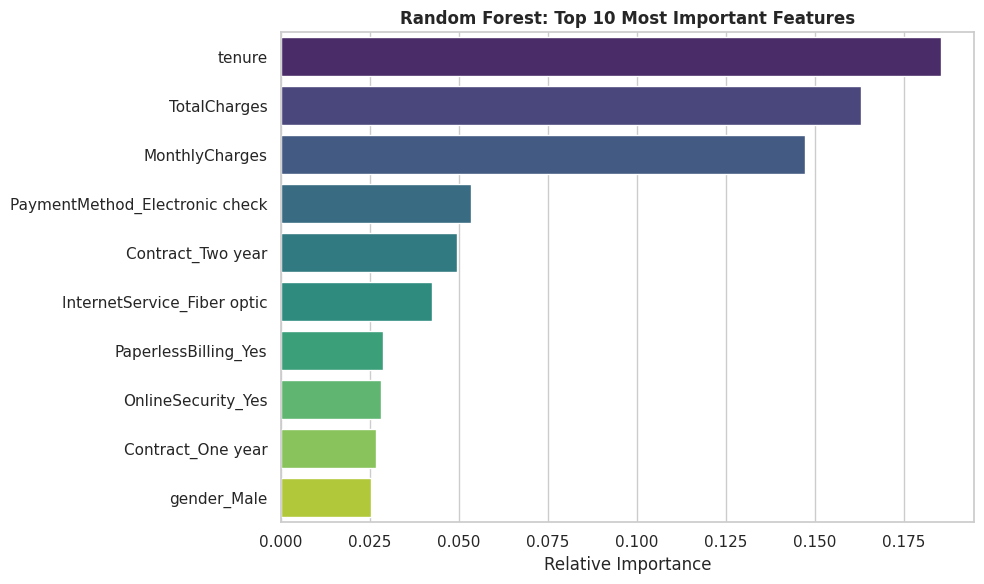

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the visual style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOGISTIC REGRESSION: DRIVERS OF CHURN
# ==========================================
# Extract coefficients and pair them with the column names
coefficients = log_reg.coef_[0]
feature_names = X_train_balanced.columns

# Create a DataFrame and sort it
coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)

# Grab the top 5 (Causes Churn) and bottom 5 (Prevents Churn)
top_bottom_coeffs = pd.concat([coeff_df.head(5), coeff_df.tail(5)])

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=top_bottom_coeffs, palette='coolwarm')
plt.title('Logistic Regression: Top Drivers (+) and Preventers (-) of Churn', fontweight='bold')
plt.xlabel('Coefficient Value (Impact on Churn)')
plt.ylabel('')
plt.tight_layout()
plt.show()

# ==========================================
# 2. RANDOM FOREST: FEATURE IMPORTANCE
# ==========================================
# Extract importance scores
importances = rf_model.feature_importances_

# Create a DataFrame and sort it
rf_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(10), palette='viridis')
plt.title('Random Forest: Top 10 Most Important Features', fontweight='bold')
plt.xlabel('Relative Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [13]:
import joblib

# Save the model and scaler (compress=3 shrinks the file size for GitHub!)
joblib.dump(rf_model, 'churn_rf_model.pkl', compress=3)
joblib.dump(scaler, 'churn_scaler.pkl')

# Save the exact expected column names from the training data
joblib.dump(list(X_train_balanced.columns), 'expected_columns.pkl')

print("Model, Scaler, and Columns saved successfully!")

Model, Scaler, and Columns saved successfully!


In [14]:
!pip install -q streamlit
!npm install localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 61.5 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 3s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

In [15]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# 1. Load the saved assets
model = joblib.load('churn_rf_model.pkl')
scaler = joblib.load('churn_scaler.pkl')
expected_columns = joblib.load('expected_columns.pkl')

st.set_page_config(page_title="Customer Churn Predictor", layout="centered")

# 2. Build the UI
st.title("🚨 Customer Churn Risk Analyzer")
st.write("Enter the customer's profile below to calculate their risk of canceling service.")

st.markdown("### Customer Profile")
col1, col2 = st.columns(2)

with col1:
    tenure = st.slider("Tenure (Months with company)", 0, 72, 12)
    contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
    paperless = st.selectbox("Paperless Billing", ["Yes", "No"])

with col2:
    monthly_charges = st.number_input("Monthly Charges ($)", min_value=15.0, max_value=120.0, value=70.0)
    total_charges = st.number_input("Total Charges ($)", min_value=15.0, max_value=8000.0, value=840.0)
    internet_service = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
    payment_method = st.selectbox("Payment Method", [
        "Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"
    ])

# 3. Process Input and Predict
if st.button("Calculate Churn Risk", type="primary"):

    # Put inputs into a DataFrame
    input_dict = {
        'tenure': [tenure],
        'MonthlyCharges': [monthly_charges],
        'TotalCharges': [total_charges],
        'Contract': [contract],
        'PaperlessBilling': [paperless],
        'InternetService': [internet_service],
        'PaymentMethod': [payment_method],
        # Fill remaining required categorical fields with safe default assumptions
        'gender': ['Male'],
        'SeniorCitizen': [0],
        'Partner': ['No'],
        'Dependents': ['No'],
        'PhoneService': ['Yes'],
        'MultipleLines': ['No'],
        'OnlineSecurity': ['No'],
        'OnlineBackup': ['No'],
        'DeviceProtection': ['No'],
        'TechSupport': ['No'],
        'StreamingTV': ['No'],
        'StreamingMovies': ['No']
    }

    input_df = pd.DataFrame(input_dict)

    # Apply One-Hot Encoding
    input_encoded = pd.get_dummies(input_df, drop_first=True)

    # MAGIC TRICK: Align the new encoded columns with the exact columns the model expects
    # If a column is missing (e.g., the user didn't pick Fiber Optic), it fills it with 0.
    input_encoded = input_encoded.reindex(columns=expected_columns, fill_value=0)

    # Scale the numerical columns
    numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
    input_encoded[numerical_columns] = scaler.transform(input_encoded[numerical_columns])

    # Get Probability of Churn (Class 1)
    churn_probability = model.predict_proba(input_encoded)[0][1]
    risk_percentage = churn_probability * 100

    # 4. Display the Results
    st.markdown("---")
    st.subheader("Analysis Results")

    # Visual Risk Gauge
    if risk_percentage > 50:
        st.error(f"High Risk of Churn: {risk_percentage:.1f}%")
        st.progress(int(risk_percentage))
        st.write("**Recommendation:** High flight risk. Immediately offer a promo code or attempt to lock them into a 1-year contract.")
    elif risk_percentage > 30:
        st.warning(f"Moderate Risk of Churn: {risk_percentage:.1f}%")
        st.progress(int(risk_percentage))
        st.write("**Recommendation:** Monitor this account closely. Ensure they are satisfied with their current tech support.")
    else:
        st.success(f"Low Risk of Churn: {risk_percentage:.1f}%")
        st.progress(int(risk_percentage))
        st.write("**Recommendation:** Healthy account. No immediate action required.")

Writing app.py


In [16]:
import urllib
print("Password/Endpoint IP for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))

Password/Endpoint IP for localtunnel is: 136.109.182.192


In [18]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

your url is: https://wild-ducks-bet.loca.lt
2026-05-02 20:37:21.144 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.109.182.192:8501

136.109.182.192
  Stopping...
^C
